In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt


with open("data.pkl", "rb") as f:
    data = pickle.load(f)

# Put your CALCULATED/PREDICTED pickle file here
W_pred_list = data["pred_list"]

# Put your EXACT TGV pickle file here
W_exact_list = data["exact_list"]

In [12]:
print("Predicted matrices :", len(W_pred_list))
print("Exact matrices     :", len(W_exact_list))

print("Predicted shape    :", W_pred_list[0].shape)
print("Exact shape        :", W_exact_list[0].shape)

Predicted matrices : 80
Exact matrices     : 80
Predicted shape    : (100, 100)
Exact shape        : (100, 100)


Stored times:
[0.     0.0125 0.025  0.0375 0.05   0.0625 0.075  0.0875 0.1    0.1125
 0.125  0.1375 0.15   0.1625 0.175  0.1875 0.2    0.2125 0.225  0.2375
 0.25   0.2625 0.275  0.2875 0.3    0.3125 0.325  0.3375 0.35   0.3625
 0.375  0.3875 0.4    0.4125 0.425  0.4375 0.45   0.4625 0.475  0.4875
 0.5    0.5125 0.525  0.5375 0.55   0.5625 0.575  0.5875 0.6    0.6125
 0.625  0.6375 0.65   0.6625 0.675  0.6875 0.7    0.7125 0.725  0.7375
 0.75   0.7625 0.775  0.7875 0.8    0.8125 0.825  0.8375 0.85   0.8625
 0.875  0.8875 0.9    0.9125 0.925  0.9375 0.95   0.9625 0.975  0.9875]

X slice
Requested x : 1.5707963267948966
Actual x    : 1.5707963267948968
Index       : 25


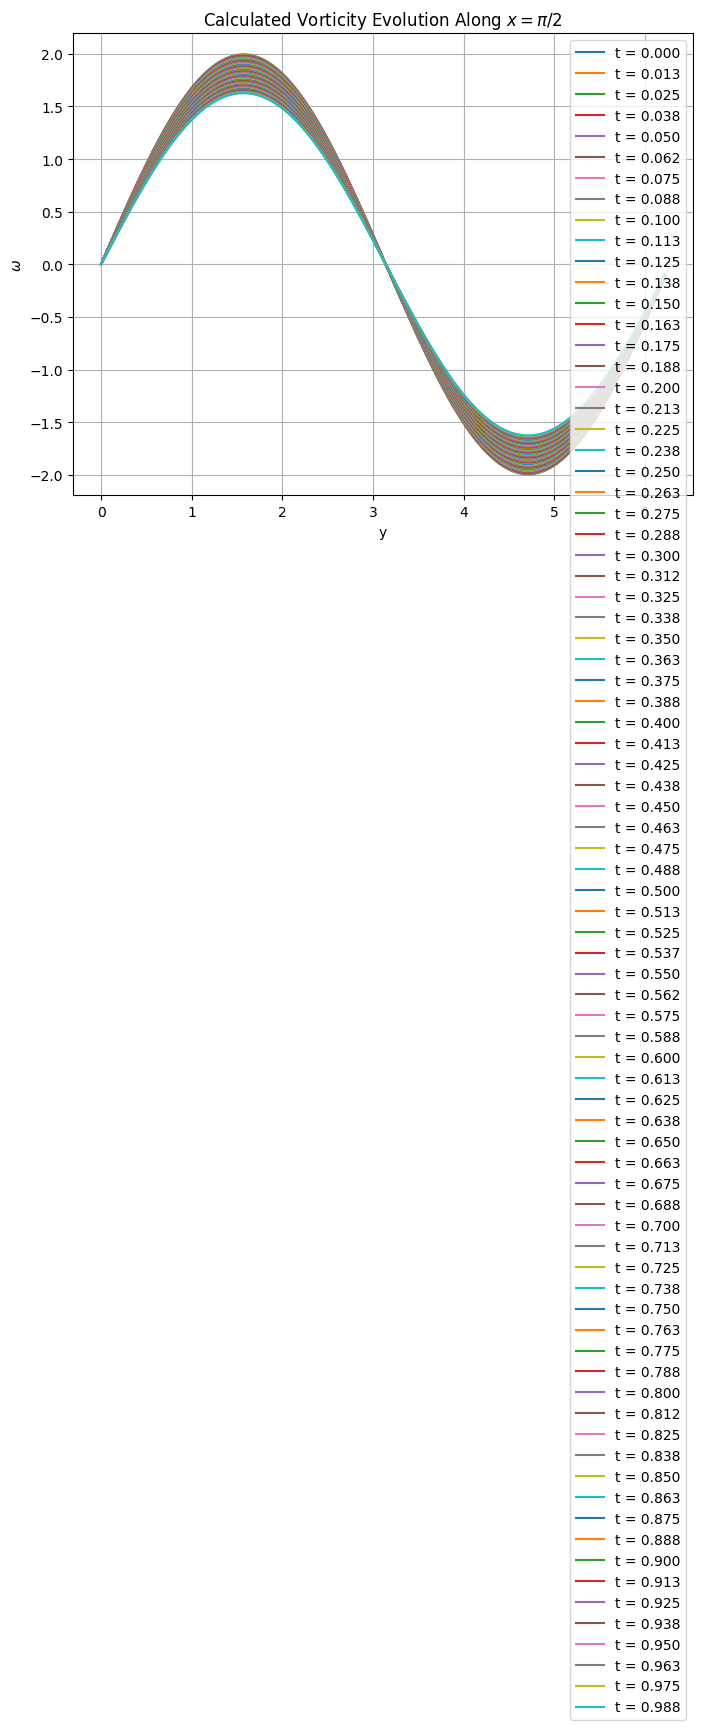


Y slice
Requested y : 1.5707963267948966
Actual y    : 1.5707963267948968
Index       : 25


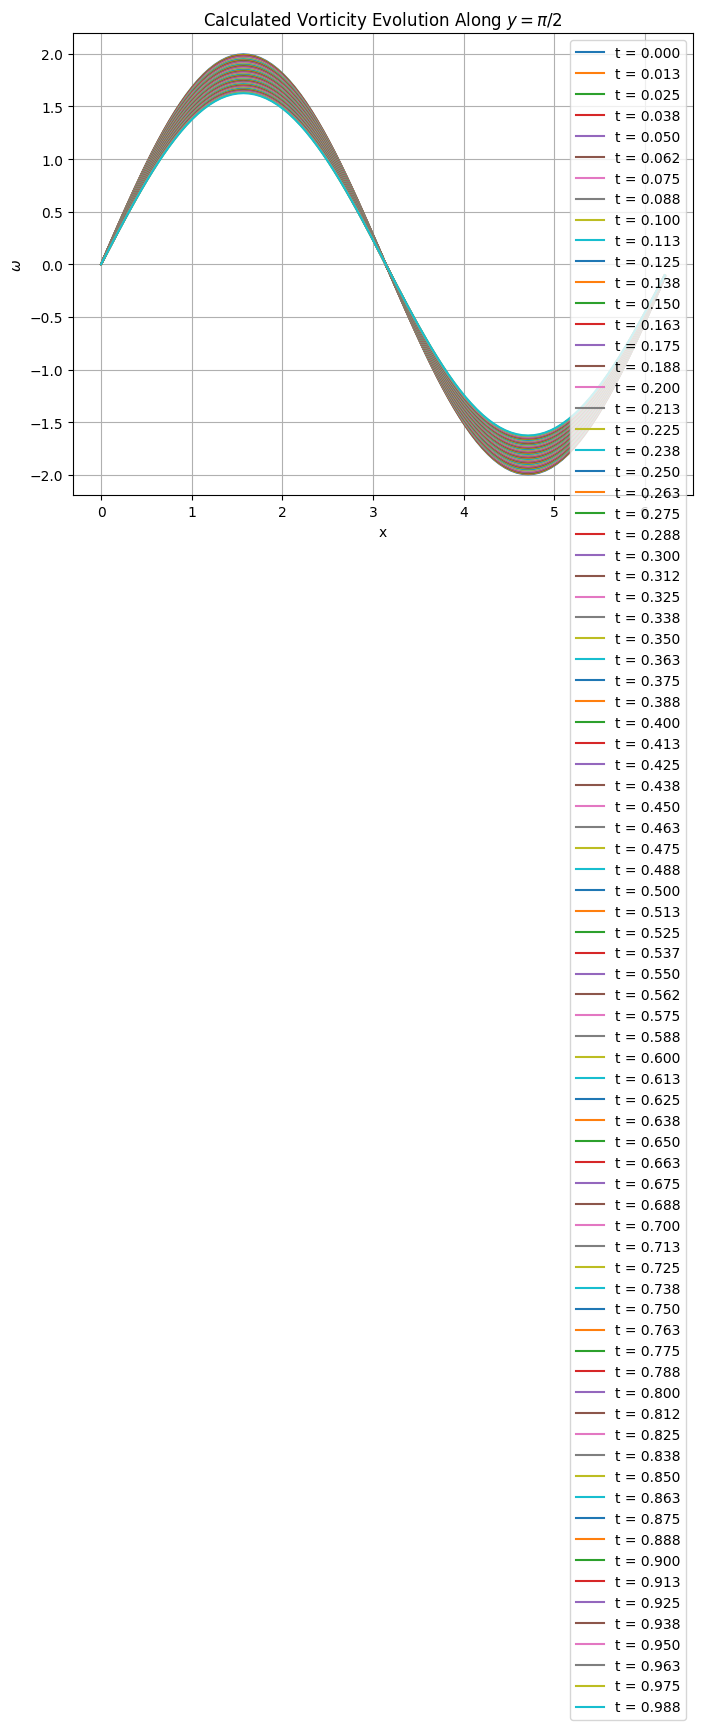

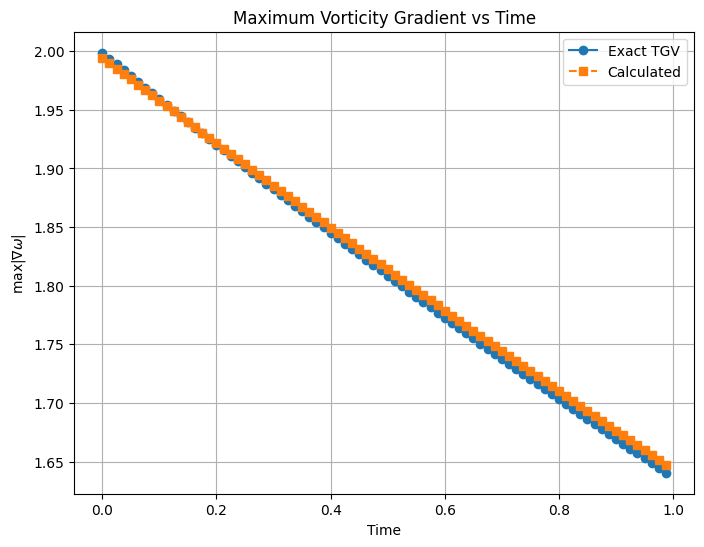


Maximum vorticity gradient
t = 0.000   Exact = 1.99868431e+00   Calculated = 1.99414462e+00   Error = 4.53968768e-03
t = 0.013   Exact = 1.99369384e+00   Calculated = 1.98960390e+00   Error = 4.08993775e-03
t = 0.025   Exact = 1.98871583e+00   Calculated = 1.98506232e+00   Error = 3.65351494e-03
t = 0.038   Exact = 1.98375025e+00   Calculated = 1.98052006e+00   Error = 3.23019338e-03
t = 0.050   Exact = 1.97879707e+00   Calculated = 1.97597734e+00   Error = 2.81973442e-03
t = 0.062   Exact = 1.97385626e+00   Calculated = 1.97143436e+00   Error = 2.42189226e-03
t = 0.075   Exact = 1.96892778e+00   Calculated = 1.96689136e+00   Error = 2.03641667e-03
t = 0.088   Exact = 1.96401161e+00   Calculated = 1.96234855e+00   Error = 1.66305442e-03
t = 0.100   Exact = 1.95910771e+00   Calculated = 1.95780616e+00   Error = 1.30155040e-03
t = 0.113   Exact = 1.95421606e+00   Calculated = 1.95326441e+00   Error = 9.51648382e-04
t = 0.125   Exact = 1.94933662e+00   Calculated = 1.94872353e+00   Error

In [ ]:
dt = 0.00125
store_every = 10

dt_store = dt * store_every

Nx, Ny = W_pred_list[0].shape

L = 2 * np.pi
B = 2 * np.pi

h = L / Nx




times = np.arange(len(W_pred_list)) * dt_store

print("Stored times:")
print(times)




x = np.arange(Nx) * h
y = np.arange(Ny) * h




x_target = np.pi / 2

ix = np.argmin(np.abs(x - x_target))

print("\nX slice")
print("Requested x :", x_target)
print("Actual x    :", x[ix])
print("Index       :", ix)


plt.figure(figsize=(8, 6))

for n, W in enumerate(W_pred_list):

    plt.plot(
        y,
        W[ix, :],
        label=f"t = {times[n]:.3f}"
    )

plt.xlabel("y")
plt.ylabel(r"$\omega$")
plt.title(r"Calculated Vorticity Evolution Along $x=\pi/2$")
plt.legend()
plt.grid()
plt.show()




y_target = np.pi / 2

iy = np.argmin(np.abs(y - y_target))

print("\nY slice")
print("Requested y :", y_target)
print("Actual y    :", y[iy])
print("Index       :", iy)


plt.figure(figsize=(8, 6))

for n, W in enumerate(W_pred_list):

    plt.plot(
        x,
        W[:, iy],
        label=f"t = {times[n]:.3f}"
    )

plt.xlabel("x")
plt.ylabel(r"$\omega$")
plt.title(r"Calculated Vorticity Evolution Along $y=\pi/2$")
plt.legend()
plt.grid()
plt.show()




def max_vorticity_gradient(W, h):

    dWdx = (
        np.roll(W, -1, axis=0)
        -
        np.roll(W, 1, axis=0)
    ) / (2 * h)

    dWdy = (
        np.roll(W, -1, axis=1)
        -
        np.roll(W, 1, axis=1)
    ) / (2 * h)

    grad_mag = np.sqrt(dWdx**2 + dWdy**2)

    return np.max(grad_mag)


grad_pred = np.array([
    max_vorticity_gradient(W, h)
    for W in W_pred_list
])

grad_exact = np.array([
    max_vorticity_gradient(W, h)
    for W in W_exact_list
])




plt.figure(figsize=(8, 6))

plt.plot(
    times,
    grad_exact,
    'o-',
    label="Exact TGV"
)

plt.plot(
    times,
    grad_pred,
    's--',
    label="Calculated"
)

plt.xlabel("Time")
plt.ylabel(r"$\max |\nabla\omega|$")
plt.title("Maximum Vorticity Gradient vs Time")

plt.legend()
plt.grid()
plt.show()



print("\nMaximum vorticity gradient")
print("=" * 70)

for t, ge, gp in zip(times, grad_exact, grad_pred):

    print(
        f"t = {t:.3f}   "
        f"Exact = {ge:.8e}   "
        f"Calculated = {gp:.8e}   "
        f"Error = {abs(gp-ge):.8e}"
    )

In [19]:
# USER INPUTS

Re = 10.0

L = 2*np.pi
B = 2*np.pi

Nxp = 100
Nyp = 100

# One time value for every matrix
times = np.array([i for i in range(80)])

import pickle

with open("data.pkl", "rb") as f:
    data = pickle.load(f)

# Replace these with your own matrices
exact_list = data["exact_list"]
predicted_list   = data["pred_list"]

"""exact_list_re = data["exact_list_re"]
pred_list_re   = data["pred_list_re"]"""


# Point at which vorticity is monitored through time
x_profile = np.pi/2
y_profile = np.pi/2


In [20]:


dx = L/Nxp
dy = B/Nyp
dA = dx*dy

x = np.linspace(0, L, Nxp, endpoint=False)
y = np.linspace(0, B, Nyp, endpoint=False)

X, Y = np.meshgrid(x, y, indexing="ij")

ix = np.argmin(np.abs(x - x_profile))
iy = np.argmin(np.abs(y - y_profile))

x_used = x[ix]
y_used = y[iy]

print("Requested point :", (x_profile, y_profile))
print("Grid point used :", (x_used, y_used))


Requested point : (1.5707963267948966, 1.5707963267948966)
Grid point used : (np.float64(1.5707963267948968), np.float64(1.5707963267948968))


In [21]:
len(exact_list), len(predicted_list)

(80, 80)

In [22]:

if len(exact_list) == 0 or len(predicted_list) == 0:
    raise ValueError("Insert exact_list and predicted_list first.")

if len(exact_list) != len(predicted_list):
    raise ValueError("Both lists must contain the same number of matrices.")

if len(times) != len(exact_list):
    raise ValueError("times must have one entry per matrix.")

for i, W in enumerate(exact_list):
    if np.asarray(W).shape != (Nxp, Nyp):
        raise ValueError(f"Exact matrix {i} has shape {np.asarray(W).shape}; expected {(Nxp,Nyp)}.")

for i, W in enumerate(predicted_list):
    if np.asarray(W).shape != (Nxp, Nyp):
        raise ValueError(f"Predicted matrix {i} has shape {np.asarray(W).shape}; expected {(Nxp,Nyp)}.")

print(f"Validated {len(times)} time steps of {Nxp} x {Nyp} matrices.")


Validated 80 time steps of 100 x 100 matrices.


In [23]:


def l2_error(W_exact, W_pred):
    return np.sqrt(np.sum((W_pred-W_exact)**2)*dA)

def relative_l2_error(W_exact, W_pred):
    denominator = np.sqrt(np.sum(W_exact**2)*dA)
    if denominator == 0:
        return np.nan
    return l2_error(W_exact, W_pred)/denominator

def circulation(W):
    return np.sum(W)*dA

def enstrophy(W):
    return 0.5*np.sum(W**2)*dA

def energy_dissipation(Z):
    # Non-dimensional kinetic-energy dissipation rate
    return (2.0/Re)*Z


In [24]:


l2_errors = []
relative_errors = []

max_exact, max_predicted = [], []
avg_exact, avg_predicted = [], []
circulation_exact, circulation_predicted = [], []
enstrophy_exact, enstrophy_predicted = [], []
dissipation_exact, dissipation_predicted = [], []
profile_exact, profile_predicted = [], []

for We, Wp in zip(exact_list, predicted_list):

    We = np.asarray(We)
    Wp = np.asarray(Wp)

    l2_errors.append(l2_error(We, Wp))
    relative_errors.append(relative_l2_error(We, Wp))

    max_exact.append(np.max(np.abs(We)))
    max_predicted.append(np.max(np.abs(Wp)))

    avg_exact.append(np.mean(We))
    avg_predicted.append(np.mean(Wp))

    circulation_exact.append(circulation(We))
    circulation_predicted.append(circulation(Wp))

    Ze = enstrophy(We)
    Zp = enstrophy(Wp)

    enstrophy_exact.append(Ze)
    enstrophy_predicted.append(Zp)

    dissipation_exact.append(energy_dissipation(Ze))
    dissipation_predicted.append(energy_dissipation(Zp))

    profile_exact.append(We[ix, iy])
    profile_predicted.append(Wp[ix, iy])

# Convert to arrays
l2_errors = np.asarray(l2_errors)
relative_errors = np.asarray(relative_errors)
max_exact, max_predicted = map(np.asarray, (max_exact, max_predicted))
avg_exact, avg_predicted = map(np.asarray, (avg_exact, avg_predicted))
circulation_exact, circulation_predicted = map(np.asarray, (circulation_exact, circulation_predicted))
enstrophy_exact, enstrophy_predicted = map(np.asarray, (enstrophy_exact, enstrophy_predicted))
dissipation_exact, dissipation_predicted = map(np.asarray, (dissipation_exact, dissipation_predicted))
profile_exact, profile_predicted = map(np.asarray, (profile_exact, profile_predicted))

print("All metrics calculated.")


All metrics calculated.


In [25]:


results = pd.DataFrame({
    "Time": times,
    "L2 Error": l2_errors,
    "Relative L2 Error": relative_errors,
    "Max |ω| Exact": max_exact,
    "Max |ω| Predicted": max_predicted,
    "Average ω Exact": avg_exact,
    "Average ω Predicted": avg_predicted,
    "Circulation Exact": circulation_exact,
    "Circulation Predicted": circulation_predicted,
    "Enstrophy Exact": enstrophy_exact,
    "Enstrophy Predicted": enstrophy_predicted,
    "Dissipation Exact": dissipation_exact,
    "Dissipation Predicted": dissipation_predicted,
    "ω at selected point Exact": profile_exact,
    "ω at selected point Predicted": profile_predicted
})

results


,Time,L2 Error,Relative L2 Error,Max |ω| Exact,Max |ω| Predicted,Average ω Exact,Average ω Predicted,Circulation Exact,Circulation Predicted,Enstrophy Exact,Enstrophy Predicted,Dissipation Exact,Dissipation Predicted,ω at selected point Exact,ω at selected point Predicted
0,0,0.015880,0.002527,2.000000,1.994700,-7.105427e-19,1.421085e-18,-2.805110e-17,5.610221e-17,19.739209,19.639607,3.947842,3.927921,2.000000,1.994700
1,1,0.016046,0.002560,1.995006,1.989418,7.105427e-19,4.263256e-18,2.805110e-17,1.683066e-16,19.640759,19.540514,3.928152,3.908103,1.995006,1.989418
2,2,0.016223,0.002595,1.990025,1.984155,2.842171e-18,2.842171e-18,1.122044e-16,1.122044e-16,19.542800,19.441927,3.908560,3.888385,1.990025,1.984155
3,3,0.016410,0.002631,1.985056,1.978910,0.000000e+00,3.552714e-18,0.000000e+00,1.402555e-16,19.445330,19.343843,3.889066,3.868769,1.985056,1.978910
4,4,0.016607,0.002670,1.980100,1.973683,3.552714e-18,2.842171e-18,1.402555e-16,1.122044e-16,19.348346,19.246260,3.869669,3.849252,1.980100,1.973683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,0.028525,0.005476,1.658058,1.642520,0.000000e+00,-1.776357e-17,0.000000e+00,-7.012776e-16,13.566547,13.449029,2.713309,2.689806,1.658058,1.642520
76,76,0.028592,0.005503,1.653918,1.638344,2.842171e-18,-1.847411e-17,1.122044e-16,-7.293287e-16,13.498883,13.381418,2.699777,2.676284,1.653918,1.638344
77,77,0.028658,0.005529,1.649789,1.634180,-2.842171e-18,-2.415845e-17,-1.122044e-16,-9.537375e-16,13.431557,13.314150,2.686311,2.662830,1.649789,1.634180
78,78,0.028721,0.005555,1.645669,1.630028,-7.105427e-19,-2.273737e-17,-2.805110e-17,-8.976353e-16,13.364567,13.247223,2.672913,2.649445,1.645669,1.630028


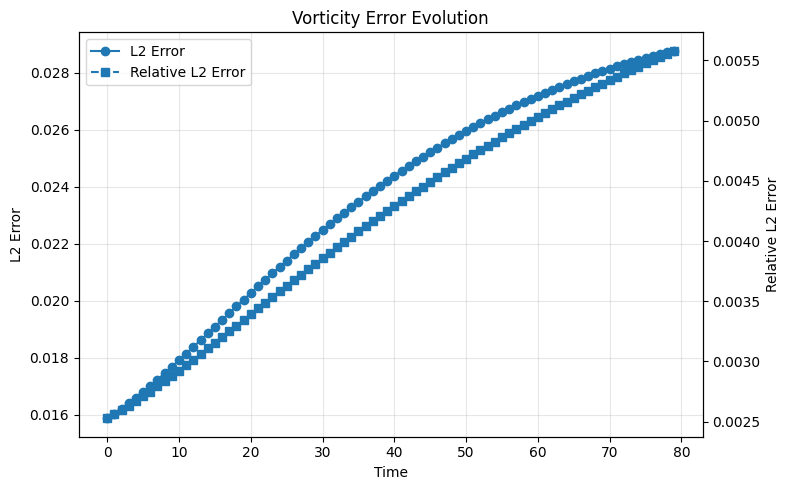

In [26]:
# L2 and relative L2 error
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(times, l2_errors, 'o-', label='L2 Error')
ax1.set_xlabel('Time')
ax1.set_ylabel('L2 Error')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(times, relative_errors, 's--', label='Relative L2 Error')
ax2.set_ylabel('Relative L2 Error')

h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2)

plt.title('Vorticity Error Evolution')
plt.tight_layout()
plt.show()


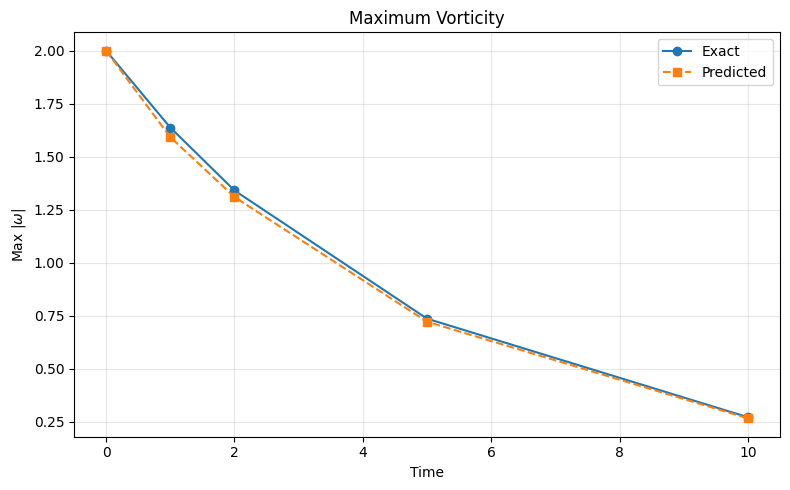

In [17]:
# Maximum vorticity
plt.figure(figsize=(8,5))
plt.plot(times, max_exact, 'o-', label='Exact')
plt.plot(times, max_predicted, 's--', label='Predicted')
plt.xlabel('Time')
plt.ylabel(r'Max $|\omega|$')
plt.title('Maximum Vorticity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


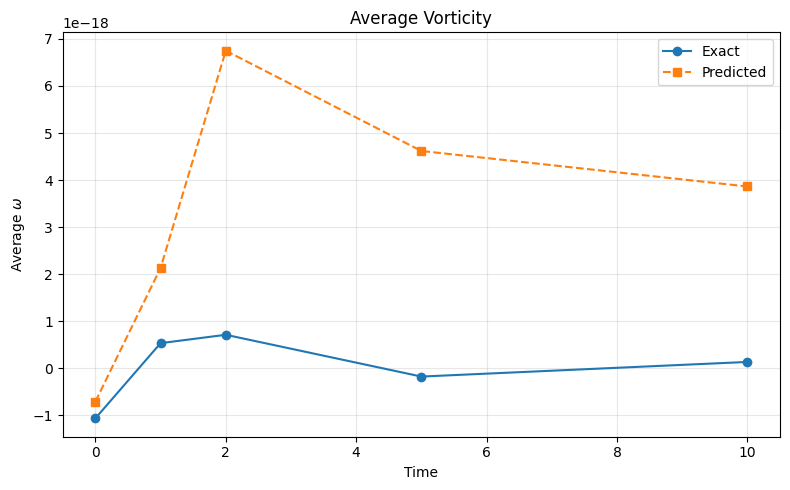

In [18]:
# Average vorticity
plt.figure(figsize=(8,5))
plt.plot(times, avg_exact, 'o-', label='Exact')
plt.plot(times, avg_predicted, 's--', label='Predicted')
plt.xlabel('Time')
plt.ylabel(r'Average $\omega$')
plt.title('Average Vorticity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


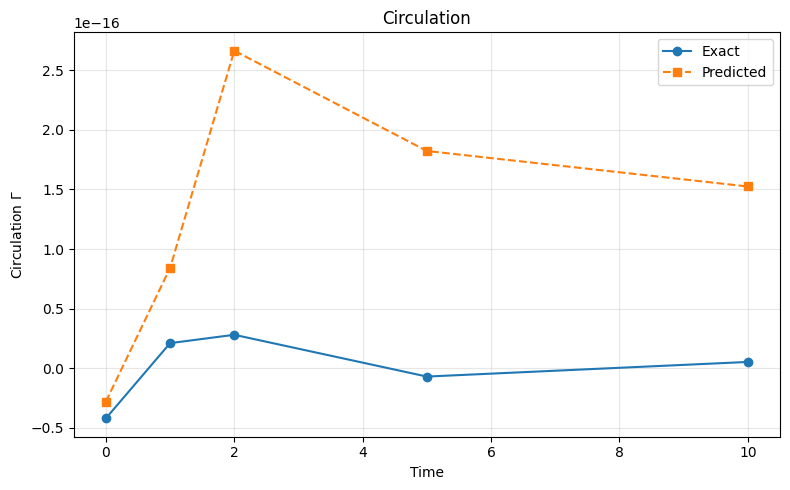

In [19]:
# Circulation
plt.figure(figsize=(8,5))
plt.plot(times, circulation_exact, 'o-', label='Exact')
plt.plot(times, circulation_predicted, 's--', label='Predicted')
plt.xlabel('Time')
plt.ylabel(r'Circulation $\Gamma$')
plt.title('Circulation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


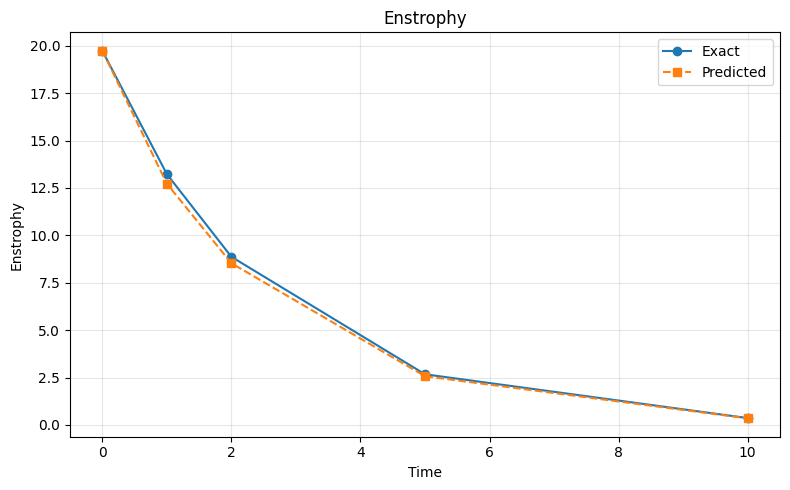

In [20]:
# Enstrophy
plt.figure(figsize=(8,5))
plt.plot(times, enstrophy_exact, 'o-', label='Exact')
plt.plot(times, enstrophy_predicted, 's--', label='Predicted')
plt.xlabel('Time')
plt.ylabel('Enstrophy')
plt.title('Enstrophy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


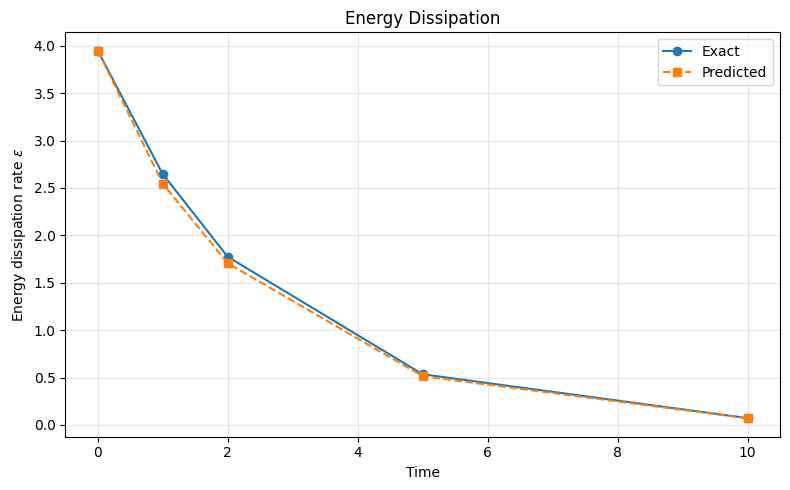

In [21]:
# Energy dissipation
plt.figure(figsize=(8,5))
plt.plot(times, dissipation_exact, 'o-', label='Exact')
plt.plot(times, dissipation_predicted, 's--', label='Predicted')
plt.xlabel('Time')
plt.ylabel(r'Energy dissipation rate $\varepsilon$')
plt.title('Energy Dissipation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


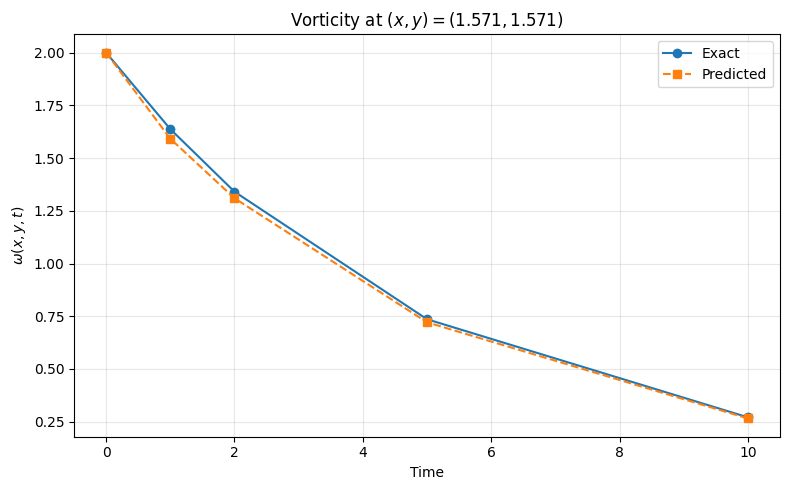

In [22]:
# Vorticity at selected point
plt.figure(figsize=(8,5))
plt.plot(times, profile_exact, 'o-', label='Exact')
plt.plot(times, profile_predicted, 's--', label='Predicted')
plt.xlabel('Time')
plt.ylabel(r'$\omega(x,y,t)$')
plt.title(rf'Vorticity at $(x,y)=({x_used:.3f},{y_used:.3f})$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Combined figure

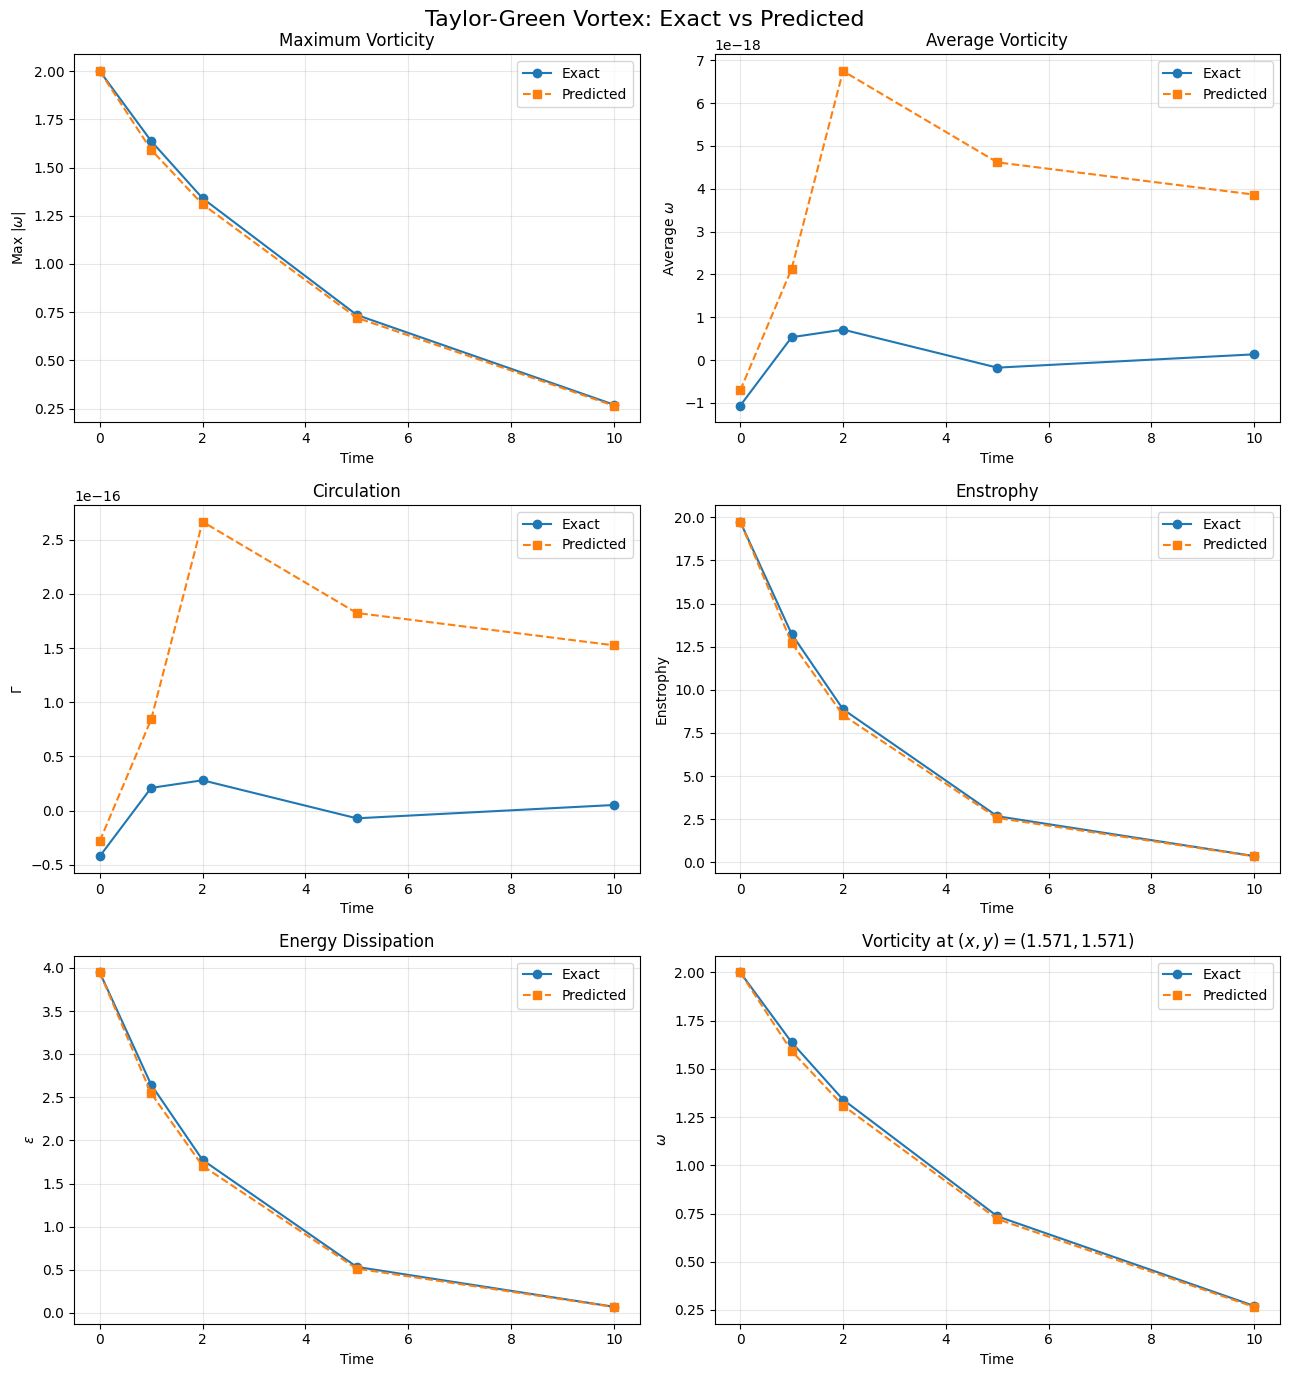

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(13,14))

plots = [
    (max_exact, max_predicted, 'Maximum Vorticity', r'Max $|\omega|$'),
    (avg_exact, avg_predicted, 'Average Vorticity', r'Average $\omega$'),
    (circulation_exact, circulation_predicted, 'Circulation', r'$\Gamma$'),
    (enstrophy_exact, enstrophy_predicted, 'Enstrophy', 'Enstrophy'),
    (dissipation_exact, dissipation_predicted, 'Energy Dissipation', r'$\varepsilon$'),
    (profile_exact, profile_predicted,
     rf'Vorticity at $(x,y)=({x_used:.3f},{y_used:.3f})$', r'$\omega$')
]

for ax, (ye, yp, title, ylabel) in zip(axes.flat, plots):
    ax.plot(times, ye, 'o-', label='Exact')
    ax.plot(times, yp, 's--', label='Predicted')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Taylor-Green Vortex: Exact vs Predicted', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
def plot_vorticity_comparison(
    exact_list,
    predicted_list,
    times,
    L=2*np.pi,
    B=2*np.pi,
    levels=50
):
    """
    Plot exact and predicted vorticity side-by-side
    for every time step.

    Rows    -> time steps
    Columns -> Exact | Predicted
    """

    n_steps = len(times)

    # Grid
    Nxp, Nyp = exact_list[0].shape

    x = np.linspace(0, L, Nxp, endpoint=False)
    y = np.linspace(0, B, Nyp, endpoint=False)

    X, Y = np.meshgrid(x, y, indexing="ij")


    all_values = np.concatenate([
        np.asarray(W).ravel()
        for W in exact_list + predicted_list
    ])

    vmax = np.max(np.abs(all_values))
    vmin = -vmax

    contour_levels = np.linspace(vmin, vmax, levels)


    fig, axes = plt.subplots(
        nrows=n_steps,
        ncols=2,
        figsize=(11, 4.2 * n_steps),
        squeeze=False
    )


    for i, t in enumerate(times):

        W_exact = np.asarray(exact_list[i])
        W_pred = np.asarray(predicted_list[i])

        # ---------------- Exact ----------------
        cf1 = axes[i, 0].contourf(
            X,
            Y,
            W_exact,
            levels=contour_levels,
            cmap="RdBu_r",
            extend="both"
        )

        axes[i, 0].set_title(
            f"Exact — $t = {t}$",
            fontsize=12,
            pad=8
        )

        axes[i, 0].set_xlabel("$x$", fontsize=11)
        axes[i, 0].set_ylabel("$y$", fontsize=11)
        axes[i, 0].set_aspect("equal")

        # ---------------- Predicted ----------------
        cf2 = axes[i, 1].contourf(
            X,
            Y,
            W_pred,
            levels=contour_levels,
            cmap="RdBu_r",
            extend="both"
        )

        axes[i, 1].set_title(
            f"Predicted — $t = {t}$",
            fontsize=12,
            pad=8
        )

        axes[i, 1].set_xlabel("$x$", fontsize=11)
        axes[i, 1].set_ylabel("$y$", fontsize=11)
        axes[i, 1].set_aspect("equal")


    fig.suptitle(
        "Taylor–Green Vortex: Exact vs Predicted",
        fontsize=16,
        y=0.995
    )


    fig.subplots_adjust(
        left=0.07,
        right=0.88,
        bottom=0.04,
        top=0.97,
        wspace=0.20,
        hspace=0.38
    )


    cbar = fig.colorbar(
        cf2,
        ax=axes,
        location="right",
        fraction=0.025,
        pad=0.035,
        shrink=0.95
    )

    cbar.set_label(
        "Vorticity",
        fontsize=12,
        labelpad=10
    )


    plt.show()

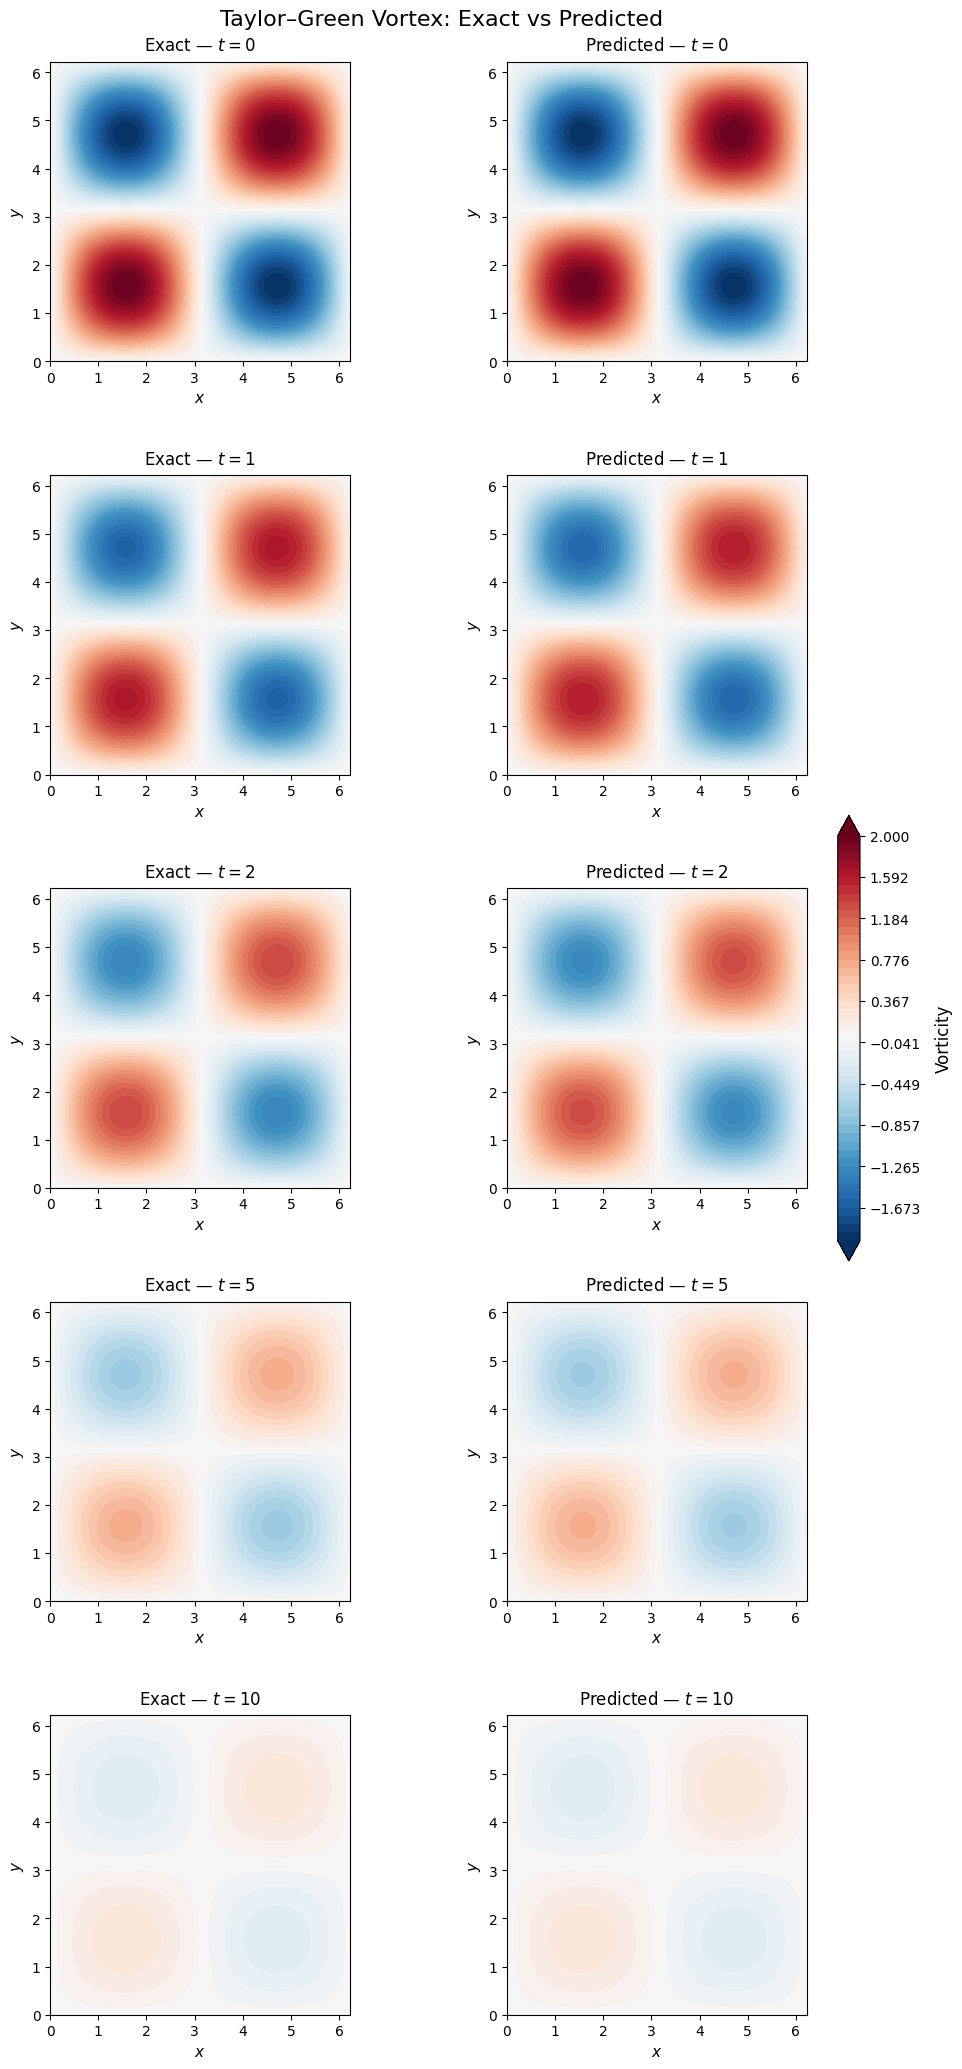

In [25]:
plot_vorticity_comparison(
    exact_list,
    predicted_list,
    times
)

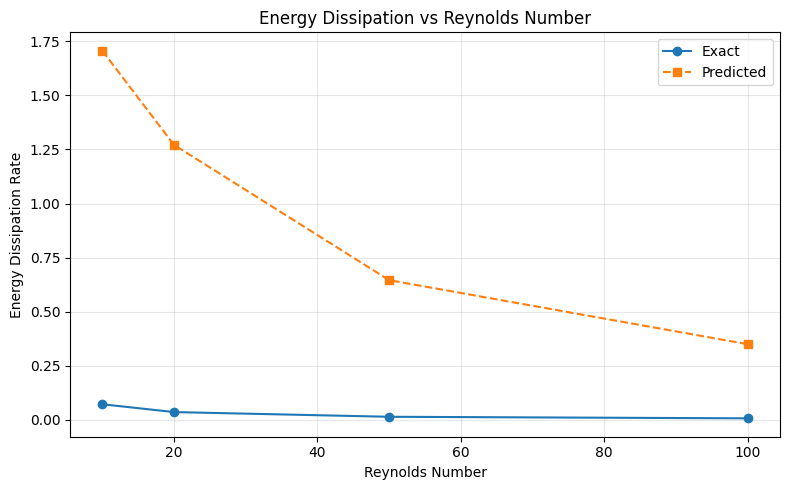

In [31]:
def calculate_enstrophy(W, L=2*np.pi, B=2*np.pi):
    Nx, Ny = W.shape

    dx = L / Nx
    dy = B / Ny

    return 0.5 * np.sum(W**2) * dx * dy


def calculate_energy_dissipation(W, Re, L=2*np.pi, B=2*np.pi):
    Z = calculate_enstrophy(W, L, B)

    return (2 / Re) * Z

Re_values = [10, 20, 50, 100]

dissipation_exact = []
dissipation_pred = []

for W_exact, W_pred, Re in zip(
    exact_list_re,
    pred_list_re,
    Re_values
):
    
    dissipation_exact.append(
        calculate_energy_dissipation(W_exact, Re)
    )
    
    dissipation_pred.append(
        calculate_energy_dissipation(W_pred, Re)
    )


plt.figure(figsize=(8, 5))

plt.plot(
    Re_values,
    dissipation_exact,
    'o-',
    label='Exact'
)

plt.plot(
    Re_values,
    dissipation_pred,
    's--',
    label='Predicted'
)

plt.xlabel("Reynolds Number")
plt.ylabel("Energy Dissipation Rate")
plt.title("Energy Dissipation vs Reynolds Number")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()